# 📦 Clase 5 — Análisis de posición y valores atípicos
## Cuartiles, percentiles y detección de outliers

**Situación:** Eres analista de satisfacción de clientes en una empresa de telecomunicaciones. El promedio es 7.5, pero un ejecutivo pregunta: *"¿Ese 7.5 representa a la mayoría? ¿Y si muchas personas evalúan con 4 y unas pocas con 10 elevan el promedio?"*

**Objetivos:**
- Calcular e interpretar **cuartiles**, **percentiles**, quintiles y deciles
- Calcular el **IQR** y aplicar la regla de los bigotes para detectar **outliers**
- Comparar distribuciones entre grupos con **boxplots**
- Contextualizar outliers antes de tomar decisiones sobre ellos
- Combinar histograma y boxplot para comunicar hallazgos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Medidas de posición

### 1.1 Cuartiles: dividir los datos en cuatro partes iguales

In [2]:
# Ejemplo exacto de la presentación
datos = pd.Series([10, 14, 18, 21, 22, 25, 30, 35, 42])

q1 = np.percentile(datos, 25)
q2 = np.percentile(datos, 50)   # = datos.median()
q3 = np.percentile(datos, 75)
iqr = q3 - q1

print(f'Datos ordenados: {sorted(datos.values)}')
print()
print(f'Q1 (25%):          {q1}   → el 25% de los datos está por debajo')
print(f'Q2 (Mediana 50%):  {q2}   → el 50% de los datos está por debajo')
print(f'Q3 (75%):          {q3}   → el 75% de los datos está por debajo')
print(f'IQR (Q3 - Q1):     {iqr}  → rango del 50% central de los datos')

Datos ordenados: [np.int64(10), np.int64(14), np.int64(18), np.int64(21), np.int64(22), np.int64(25), np.int64(30), np.int64(35), np.int64(42)]

Q1 (25%):          18.0   → el 25% de los datos está por debajo
Q2 (Mediana 50%):  22.0   → el 50% de los datos está por debajo
Q3 (75%):          30.0   → el 75% de los datos está por debajo
IQR (Q3 - Q1):     12.0  → rango del 50% central de los datos


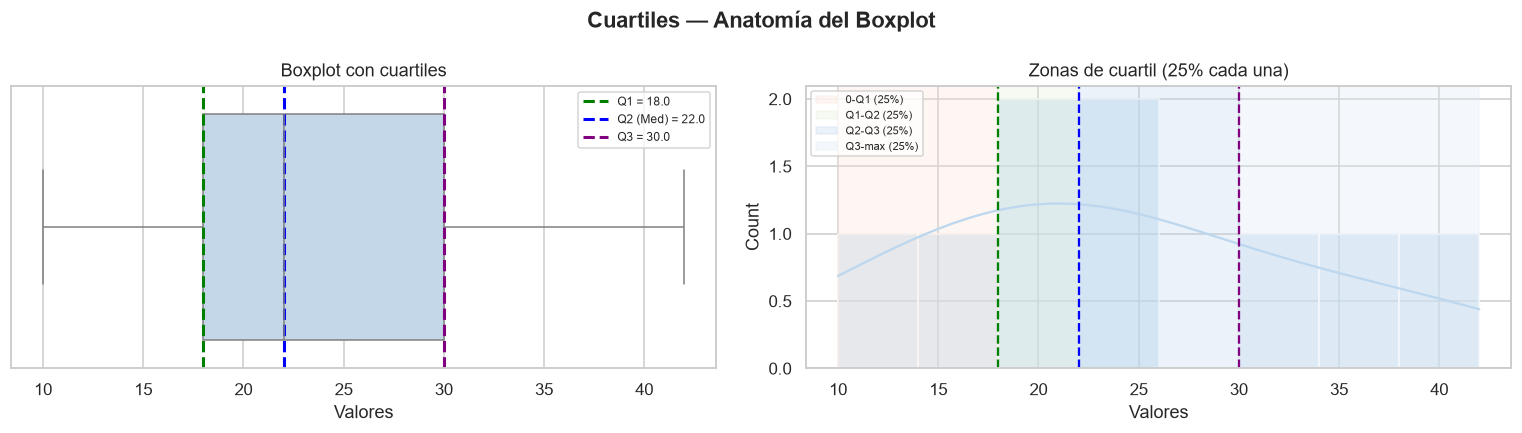

In [3]:
# Visualizar los cuartiles sobre el boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Cuartiles — Anatomía del Boxplot', fontweight='bold')

# Boxplot horizontal con anotaciones
sns.boxplot(x=datos, ax=axes[0], color='#BDD7EE')
for val, lbl, col in [(q1,'Q1','green'), (q2,'Q2 (Med)','blue'), (q3,'Q3','purple')]:
    axes[0].axvline(val, color=col, linestyle='--', linewidth=2, label=f'{lbl} = {val}')
axes[0].set_title('Boxplot con cuartiles')
axes[0].set_xlabel('Valores')
axes[0].legend(fontsize=8)

# Histograma con zonas coloreadas por cuartil
sns.histplot(datos, bins=8, kde=True, ax=axes[1], color='#BDD7EE', edgecolor='white')
min_v, max_v = datos.min(), datos.max()
colores_q = ['#FCE4D6', '#E2EFDA', '#BDD7EE', '#DDEBF7']
zonas = [(min_v, q1), (q1, q2), (q2, q3), (q3, max_v)]
labels_q = ['0-Q1 (25%)', 'Q1-Q2 (25%)', 'Q2-Q3 (25%)', 'Q3-max (25%)']
for (ini, fin), col, lbl in zip(zonas, colores_q, labels_q):
    axes[1].axvspan(ini, fin, alpha=0.3, color=col, label=lbl)
for val, lbl, col in [(q1,'Q1','green'), (q2,'Q2','blue'), (q3,'Q3','purple')]:
    axes[1].axvline(val, color=col, linestyle='--', linewidth=1.5)
axes[1].set_title('Zonas de cuartil (25% cada una)')
axes[1].set_xlabel('Valores')
axes[1].legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

### 1.2 Percentiles: más precisión en la distribución

In [4]:
# Percentiles clave sobre la misma serie
percentiles_clave = [10, 25, 50, 75, 90, 95]
print('=== Percentiles clave ===')
for p in percentiles_clave:
    val = np.percentile(datos, p)
    print(f'  P{p:>2}:  {val:>6.1f}  → el {p}% de los datos está por debajo de este valor')

print()
p10 = np.percentile(datos, 10)
p90 = np.percentile(datos, 90)
print(f'Rango P10-P90 (80% central): [{p10:.1f} — {p90:.1f}]')

=== Percentiles clave ===
  P10:    13.2  → el 10% de los datos está por debajo de este valor
  P25:    18.0  → el 25% de los datos está por debajo de este valor
  P50:    22.0  → el 50% de los datos está por debajo de este valor
  P75:    30.0  → el 75% de los datos está por debajo de este valor
  P90:    36.4  → el 90% de los datos está por debajo de este valor
  P95:    39.2  → el 95% de los datos está por debajo de este valor

Rango P10-P90 (80% central): [13.2 — 36.4]


### 1.3 Quintiles y deciles

In [5]:
# Quintiles (20% cada parte) y Deciles (10% cada parte)
print('=== Quintiles (divisiones cada 20%) ===')
for i, p in enumerate([20, 40, 60, 80], 1):
    print(f'  Quintil {i} (P{p}): {np.percentile(datos, p):.1f}')

print()
print('=== Deciles (divisiones cada 10%) ===')
for i, p in enumerate(range(10, 100, 10), 1):
    print(f'  Decil {i:>2} (P{p:>2}): {np.percentile(datos, p):.1f}')

# Uso práctico desde la presentación
print()
quintil_1 = np.percentile(datos, 20)
decil_3   = np.percentile(datos, 30)
print(f'Quintil 1 (P20): {quintil_1}')
print(f'Decil 3   (P30): {decil_3}')

=== Quintiles (divisiones cada 20%) ===
  Quintil 1 (P20): 16.4
  Quintil 2 (P40): 21.2
  Quintil 3 (P60): 24.4
  Quintil 4 (P80): 32.0

=== Deciles (divisiones cada 10%) ===
  Decil  1 (P10): 13.2
  Decil  2 (P20): 16.4
  Decil  3 (P30): 19.2
  Decil  4 (P40): 21.2
  Decil  5 (P50): 22.0
  Decil  6 (P60): 24.4
  Decil  7 (P70): 28.0
  Decil  8 (P80): 32.0
  Decil  9 (P90): 36.4

Quintil 1 (P20): 16.4
Decil 3   (P30): 19.2


### ✏️ Ejercicio 1 — Completa y reflexiona:

In [8]:
ventas_equipo = pd.Series([45, 52, 61, 70, 72, 75, 80, 85, 90, 95,
                           100, 102, 108, 115, 120, 130, 145, 160, 200, 350])

# ✏️ Calcula Q1, Q2, Q3 e IQR
q1_v = np.percentile(ventas_equipo, 25)
q2_v = np.percentile(ventas_equipo, 50)
q3_v = np.percentile(ventas_equipo, 75)
iqr_v = q3_v - q1_v

print(f'Q1: {q1_v} | Q2: {q2_v} | Q3: {q3_v} | IQR: {iqr_v}')

# ✏️ ¿Cuál es el percentil 90? (vendedor de alto desempeño)
p90_v = np.percentile(ventas_equipo, 90)
print(f'Percentil 90 (alto desempeño): {p90_v}')

# ✏️ ¿Qué porcentaje del equipo vende más de 120 unidades?
pct_sobre_120 = (ventas_equipo > 120).mean() * 100
print(f'% que vende más de 120: {pct_sobre_120:.1f}%')

# ✏️ ¿Para qué usarías deciles en lugar de cuartiles en este análisis de ventas?
r_deciles = ""
print('Ventaja deciles:', r_deciles)

Q1: 74.25 | Q2: 97.5 | Q3: 122.5 | IQR: 48.25
Percentil 90 (alto desempeño): 164.00000000000006
% que vende más de 120: 25.0%
Ventaja deciles: 


---
## PARTE 2 — Detección de outliers con IQR

### 2.1 Regla de los bigotes (Tukey)

In [9]:
# Ejemplo exacto de la presentación
valores_out = [5, 6, 6, 7, 8, 9, 10, 11, 12, 30]  # 30 parece outlier

q1_o = np.percentile(valores_out, 25)
q3_o = np.percentile(valores_out, 75)
iqr_o = q3_o - q1_o
lim_inf = q1_o - 1.5 * iqr_o
lim_sup = q3_o + 1.5 * iqr_o

outliers_det = [x for x in valores_out if x < lim_inf or x > lim_sup]

print('=== Detección de outliers por IQR ===')
print(f'Datos: {valores_out}')
print(f'Q1: {q1_o} | Q3: {q3_o} | IQR: {iqr_o}')
print(f'Límite inferior: Q1 - 1.5×IQR = {q1_o} - {1.5*iqr_o} = {lim_inf:.2f}')
print(f'Límite superior: Q3 + 1.5×IQR = {q3_o} + {1.5*iqr_o} = {lim_sup:.2f}')
print(f'Outliers detectados: {outliers_det}')

=== Detección de outliers por IQR ===
Datos: [5, 6, 6, 7, 8, 9, 10, 11, 12, 30]
Q1: 6.25 | Q3: 10.75 | IQR: 4.5
Límite inferior: Q1 - 1.5×IQR = 6.25 - 6.75 = -0.50
Límite superior: Q3 + 1.5×IQR = 10.75 + 6.75 = 17.50
Outliers detectados: [30]


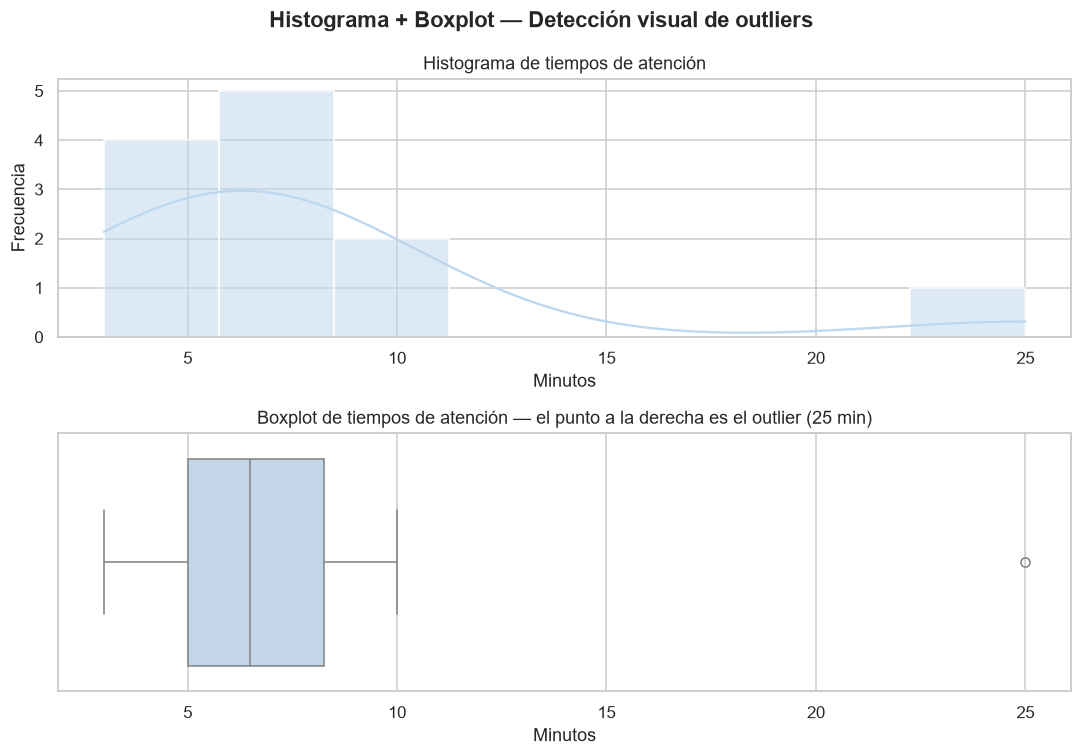

In [10]:
# Visualización: histograma + boxplot (igual que en la presentación)
valores_vis = [3, 4, 5, 5, 6, 6, 7, 7, 8, 9, 10, 25]  # incluye outlier

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle('Histograma + Boxplot — Detección visual de outliers', fontweight='bold')

# Histograma
sns.histplot(valores_vis, bins=8, kde=True, ax=axes[0], color='#BDD7EE', edgecolor='white')
axes[0].set_title('Histograma de tiempos de atención')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=valores_vis, ax=axes[1], color='#BDD7EE')
axes[1].set_title('Boxplot de tiempos de atención — el punto a la derecha es el outlier (25 min)')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()

### 2.2 Comparación: con y sin outlier

In [11]:
serie = pd.Series(valores_vis)
sin   = serie[serie <= lim_sup]

comp = pd.DataFrame({
    'Con outlier':  [serie.mean(), serie.median(), serie.std(ddof=1),
                     serie.quantile(0.25), serie.quantile(0.75)],
    'Sin outlier':  [sin.mean(),   sin.median(),   sin.std(ddof=1),
                     sin.quantile(0.25),   sin.quantile(0.75)]
}, index=['Media','Mediana','Desv.std','Q1','Q3']).round(2)
comp['Diferencia'] = (comp['Con outlier'] - comp['Sin outlier']).round(2)

print('=== Impacto del outlier en las métricas ===')
print(comp)

=== Impacto del outlier en las métricas ===
          Con outlier  Sin outlier  Diferencia
Media            7.92         6.36        1.56
Mediana          6.50         6.00        0.50
Desv.std         5.74         2.11        3.63
Q1               5.00         5.00        0.00
Q3               8.25         7.50        0.75


### ✏️ Ejercicio 2 — Responde:

In [12]:
# ✏️ ¿Qué medida se ve más afectada por el outlier (media o mediana)? ¿Por qué?
r_impacto = ""

# ✏️ ¿Siempre se debe eliminar un outlier detectado? ¿Qué preguntas deberías hacerte?
r_eliminar = ""

# ✏️ Da un ejemplo de un outlier que NO debería eliminarse y uno que SÍ:
r_no_elim = ""
r_si_elim = ""

print('Impacto outlier:', r_impacto)
print('¿Eliminar?:     ', r_eliminar)
print('No eliminar:    ', r_no_elim)
print('Sí eliminar:    ', r_si_elim)

Impacto outlier: 
¿Eliminar?:      
No eliminar:     
Sí eliminar:     


---
## PARTE 3 — Actividad guiada: ExpressLog

**Reutilizamos `entregas_express.csv` de la clase anterior para aplicar cuartiles, percentiles y detección de outliers.**

### 3.1 Cargar y explorar

In [13]:
df = pd.read_csv('entregas_express.csv')

print(f'Registros: {len(df)}')
print()
print(df.head(8))
print()
print('=== Resumen estadístico ===')
print(df['tiempo_entrega'].describe().round(2))

Registros: 80

  id_pedido  tiempo_entrega         region       canal categoria_producto
0      P001              40    Antofagasta  Telefónico            Muebles
1      P002              40      Los Lagos    Sucursal               Ropa
2      P003              49  Metropolitana  Telefónico               Ropa
3      P004              51  Metropolitana         App        Electrónica
4      P005              62    Antofagasta    Sucursal          Alimentos
5      P006              40     Valparaíso  Telefónico            Muebles
6      P007             117     Valparaíso    Sucursal               Ropa
7      P008              55     Valparaíso         App          Alimentos

=== Resumen estadístico ===
count     80.00
mean      48.40
std       21.74
min       22.00
25%       36.00
50%       43.50
75%       52.50
max      122.00
Name: tiempo_entrega, dtype: float64


### 3.2 Cuartiles y percentiles del tiempo de entrega

In [14]:
t = df['tiempo_entrega']

q1  = t.quantile(0.25)
q2  = t.quantile(0.50)
q3  = t.quantile(0.75)
p10 = t.quantile(0.10)
p90 = t.quantile(0.90)
p95 = t.quantile(0.95)
iqr = q3 - q1

print('=== Medidas de posición — Tiempo de entrega (horas) ===')
print(f'  P10 (10% más rápido):   {p10:.1f} h')
print(f'  Q1  (25%):              {q1:.1f} h')
print(f'  Q2  (Mediana):          {q2:.1f} h')
print(f'  Q3  (75%):              {q3:.1f} h')
print(f'  P90 (90%):              {p90:.1f} h')
print(f'  P95 (SLA empresarial):  {p95:.1f} h')
print(f'  IQR (Q3-Q1):            {iqr:.1f} h')
print()
print(f'  El 50% central de las entregas tarda entre {q1:.1f}h y {q3:.1f}h')
print(f'  El 90% de las entregas se completa antes de {p90:.1f}h')

=== Medidas de posición — Tiempo de entrega (horas) ===
  P10 (10% más rápido):   28.9 h
  Q1  (25%):              36.0 h
  Q2  (Mediana):          43.5 h
  Q3  (75%):              52.5 h
  P90 (90%):              70.1 h
  P95 (SLA empresarial):  99.9 h
  IQR (Q3-Q1):            16.5 h

  El 50% central de las entregas tarda entre 36.0h y 52.5h
  El 90% de las entregas se completa antes de 70.1h


### 3.3 Detectar outliers con IQR

In [15]:
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_df = df[(t < lim_inf) | (t > lim_sup)]

print(f'Límite inferior: Q1 - 1.5×IQR = {q1:.1f} - {1.5*iqr:.1f} = {lim_inf:.1f}h')
print(f'Límite superior: Q3 + 1.5×IQR = {q3:.1f} + {1.5*iqr:.1f} = {lim_sup:.1f}h')
print(f'Outliers detectados: {len(outliers_df)} de {len(df)} registros '
      f'({len(outliers_df)/len(df)*100:.1f}%)')
print()
print(outliers_df[['id_pedido','tiempo_entrega','region','canal']].to_string(index=False))

Límite inferior: Q1 - 1.5×IQR = 36.0 - 24.8 = 11.2h
Límite superior: Q3 + 1.5×IQR = 52.5 + 24.8 = 77.2h
Outliers detectados: 6 de 80 registros (7.5%)

id_pedido  tiempo_entrega        region      canal
     P007             117    Valparaíso   Sucursal
     P017             122 Metropolitana        App
     P031             119 Metropolitana   Sucursal
     P041              99        Biobío        Web
     P051              99    Valparaíso Telefónico
     P073             120        Biobío   Sucursal


### 3.4 Visualización completa

C:\Users\Natalie\AppData\Local\Temp\ipykernel_20708\1529584338.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='tiempo_entrega', order=orden_reg,


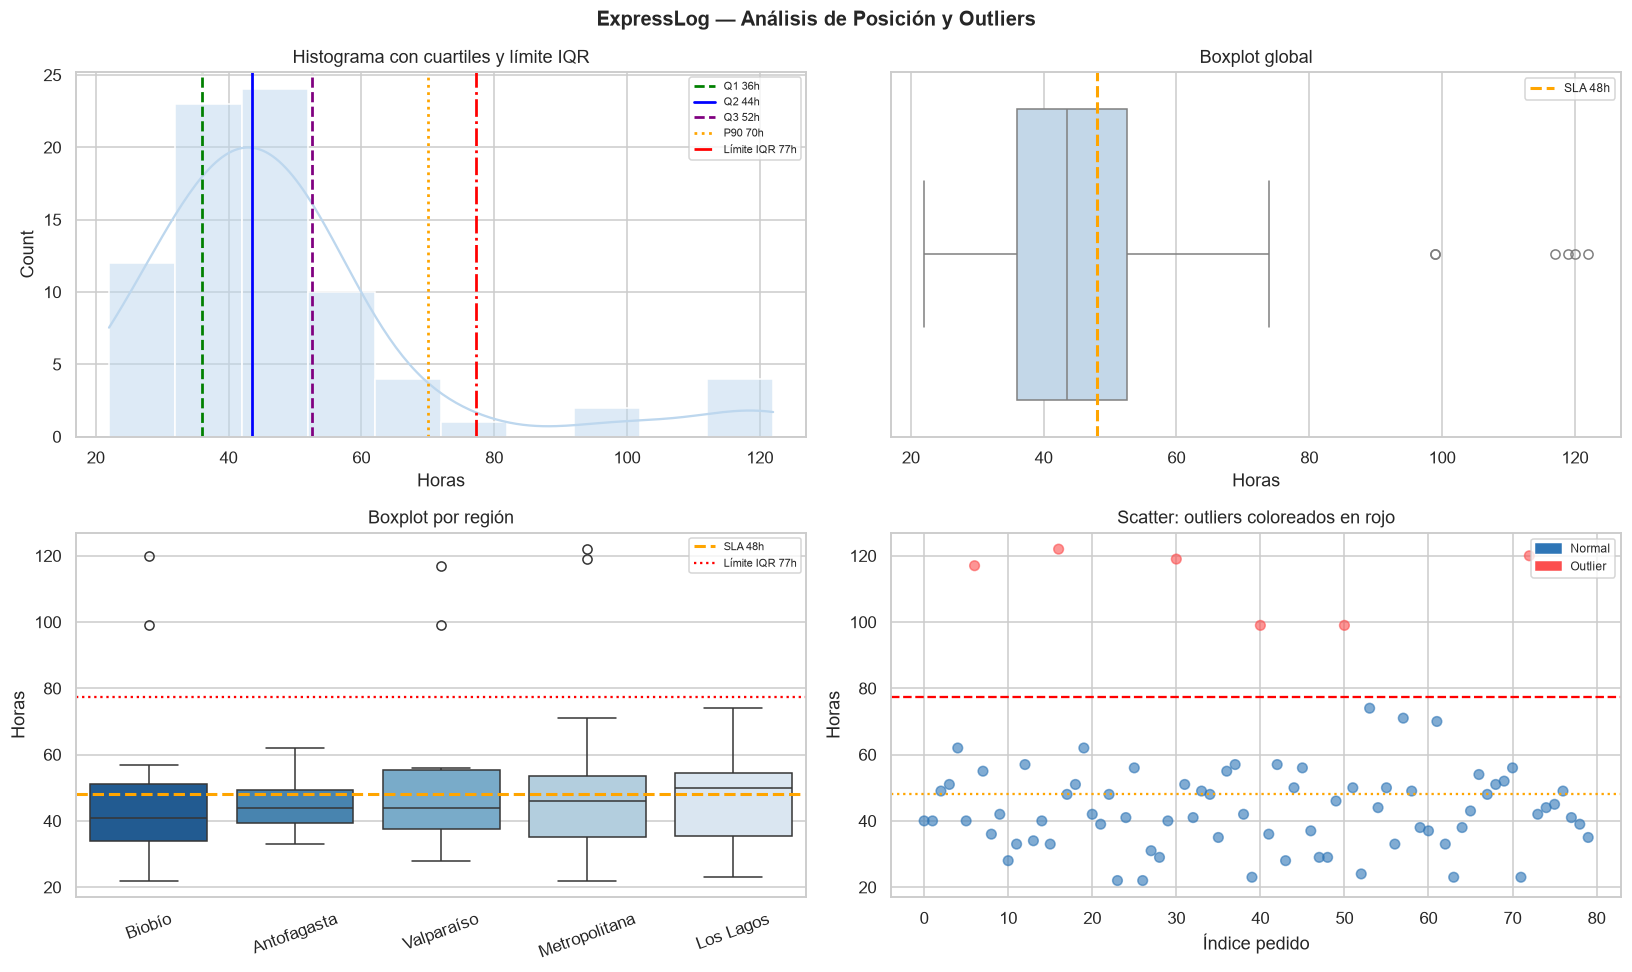

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('ExpressLog — Análisis de Posición y Outliers', fontweight='bold', fontsize=13)

# 1. Histograma con percentiles
sns.histplot(t, bins=10, kde=True, ax=axes[0,0], color='#BDD7EE', edgecolor='white')
for val, lbl, col, ls in [
    (q1, f'Q1 {q1:.0f}h', 'green', '--'),
    (q2, f'Q2 {q2:.0f}h', 'blue', '-'),
    (q3, f'Q3 {q3:.0f}h', 'purple', '--'),
    (p90, f'P90 {p90:.0f}h', 'orange', ':'),
    (lim_sup, f'Límite IQR {lim_sup:.0f}h', 'red', '-.')
]:
    axes[0,0].axvline(val, color=col, linestyle=ls, linewidth=1.8, label=lbl)
axes[0,0].set_title('Histograma con cuartiles y límite IQR')
axes[0,0].set_xlabel('Horas')
axes[0,0].legend(fontsize=7)

# 2. Boxplot global
sns.boxplot(x=t, ax=axes[0,1], color='#BDD7EE')
axes[0,1].axvline(48, color='orange', linestyle='--', linewidth=2, label='SLA 48h')
axes[0,1].set_title('Boxplot global')
axes[0,1].set_xlabel('Horas')
axes[0,1].legend(fontsize=8)

# 3. Boxplot por región
orden_reg = df.groupby('region')['tiempo_entrega'].median().sort_values().index
sns.boxplot(data=df, x='region', y='tiempo_entrega', order=orden_reg,
            palette='Blues_r', ax=axes[1,0])
axes[1,0].axhline(48, color='orange', linestyle='--', linewidth=2, label='SLA 48h')
axes[1,0].axhline(lim_sup, color='red', linestyle=':', linewidth=1.5,
                  label=f'Límite IQR {lim_sup:.0f}h')
axes[1,0].set_title('Boxplot por región')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Horas')
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].legend(fontsize=7)

# 4. Outliers coloreados en scatter
df['es_outlier'] = (t > lim_sup) | (t < lim_inf)
colores = df['es_outlier'].map({True: '#FC4E4E', False: '#2E75B6'})
axes[1,1].scatter(range(len(df)), df['tiempo_entrega'],
                  c=colores, alpha=0.6, s=40)
axes[1,1].axhline(lim_sup, color='red', linestyle='--', linewidth=1.5,
                  label=f'Límite IQR {lim_sup:.0f}h')
axes[1,1].axhline(48, color='orange', linestyle=':', linewidth=1.5, label='SLA 48h')
normal_p = mpatches.Patch(color='#2E75B6', label='Normal')
outlier_p = mpatches.Patch(color='#FC4E4E', label='Outlier')
axes[1,1].legend(handles=[normal_p, outlier_p], fontsize=8)
axes[1,1].set_title('Scatter: outliers coloreados en rojo')
axes[1,1].set_xlabel('Índice pedido')
axes[1,1].set_ylabel('Horas')

plt.tight_layout()
plt.show()

### 3.5 Segmentación por deciles para gerencia

In [17]:
# Asignar decil a cada pedido
df['decil'] = pd.qcut(df['tiempo_entrega'], q=10,
                       labels=[f'D{i}' for i in range(1,11)],
                       duplicates='drop')

resumen_decil = df.groupby('decil', observed=True)['tiempo_entrega'].agg(
    min_h='min', max_h='max', n='count'
)
resumen_decil['% acumulado'] = (resumen_decil['n'].cumsum() / len(df) * 100).round(1)

print('=== Distribución por deciles — Tiempos de entrega ===')
print(resumen_decil.to_string())
print()
print(f'D1 (10% más rápido): hasta {resumen_decil.iloc[0]["max_h"]:.0f}h')
print(f'D10 (10% más lento): desde {resumen_decil.iloc[-1]["min_h"]:.0f}h')

=== Distribución por deciles — Tiempos de entrega ===
       min_h  max_h   n  % acumulado
decil                               
D1        22     28   8         10.0
D2        29     33   8         20.0
D3        34     38   9         31.2
D4        39     40   7         40.0
D5        41     43   8         50.0
D6        44     48   8         60.0
D7        49     51  11         73.8
D8        52     56   7         82.5
D9        57     70   6         90.0
D10       71    122   8        100.0

D1 (10% más rápido): hasta 28h
D10 (10% más lento): desde 71h


### ✏️ Ejercicio 3 — Concluye:

In [18]:
# ✏️ ¿Qué región tiene los tiempos más inconsistentes según el boxplot?
r_region = ""

# ✏️ ¿Qué porcentaje de pedidos cumple el SLA de 48h?
pct_sla = (df['tiempo_entrega'] <= 48).mean() * 100
print(f'% pedidos dentro de SLA 48h: {pct_sla:.1f}%')

# ✏️ ¿Deberías eliminar los outliers antes de reportar la mediana a gerencia?
r_outliers_ger = ""

# ✏️ ¿Por qué es más útil el P90 que la media para definir tiempos máximos de entrega?
r_p90 = ""

print('Región inconsistente:', r_region)
print('¿Eliminar outliers?: ', r_outliers_ger)
print('P90 vs Media:        ', r_p90)

% pedidos dentro de SLA 48h: 60.0%
Región inconsistente: 
¿Eliminar outliers?:  
P90 vs Media:         


---
## PARTE 4 — Actividad autónoma: Satisfacción de clientes

**Situación:** Analizar las calificaciones de clientes de una empresa de telecomunicaciones. El promedio es 7.5, pero el ejecutivo sospecha que no es representativo.

### 4.1 Cargar y explorar

In [19]:
df2 = pd.read_csv('calificaciones_autonomo.csv')

print(f'Registros: {len(df2)}')
print()
print(df2.head(8))
print()
print('=== Resumen estadístico ===')
print(df2[['calificacion','tiempo_resolucion_min']].describe().round(2))

Registros: 200

  id_encuesta       fecha     segmento       canal              producto  \
0        C001  2024-03-26  Empresarial  Telefónico       Telefonía Móvil   
1        C002  2024-05-01     Gobierno        Chat  Internet Empresarial   
2        C003  2024-04-25  Residencial  Presencial            Pack Combo   
3        C004  2024-04-25  Empresarial         Web        Internet Hogar   
4        C005  2024-01-16     Gobierno        Chat       Telefonía Móvil   
5        C006  2024-02-04  Residencial  Presencial        Internet Hogar   
6        C007  2024-05-16  Residencial  Telefónico  Internet Empresarial   
7        C008  2024-04-03  Empresarial         Web        Internet Hogar   

   calificacion  tiempo_resolucion_min  
0             7                      7  
1             7                     26  
2             3                     26  
3            10                     24  
4            10                     18  
5             8                      3  
6           

### 4.2 Medidas de posición y outliers — calificación

In [20]:
c = df2['calificacion']

q1_c  = c.quantile(0.25)
q2_c  = c.quantile(0.50)
q3_c  = c.quantile(0.75)
iqr_c = q3_c - q1_c
lim_i_c = q1_c - 1.5 * iqr_c
lim_s_c = q3_c + 1.5 * iqr_c

print('=== Medidas de posición — Calificación (1-10) ===')
for p in [10, 25, 50, 75, 90]:
    print(f'  P{p:>2}: {c.quantile(p/100):.1f}')
print(f'  IQR: {iqr_c:.1f}')
print(f'  Límites IQR: [{lim_i_c:.1f} — {lim_s_c:.1f}]')
print()

out_c = df2[(c < lim_i_c) | (c > lim_s_c)]
print(f'Outliers detectados: {len(out_c)} ({len(out_c)/len(df2)*100:.1f}%)')

=== Medidas de posición — Calificación (1-10) ===
  P10: 4.0
  P25: 6.0
  P50: 7.0
  P75: 9.0
  P90: 10.0
  IQR: 3.0
  Límites IQR: [1.5 — 13.5]

Outliers detectados: 4 (2.0%)


### 4.3 Visualización completa

C:\Users\Natalie\AppData\Local\Temp\ipykernel_20708\2420346371.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='segmento', y='calificacion',
C:\Users\Natalie\AppData\Local\Temp\ipykernel_20708\2420346371.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='canal', y='calificacion',


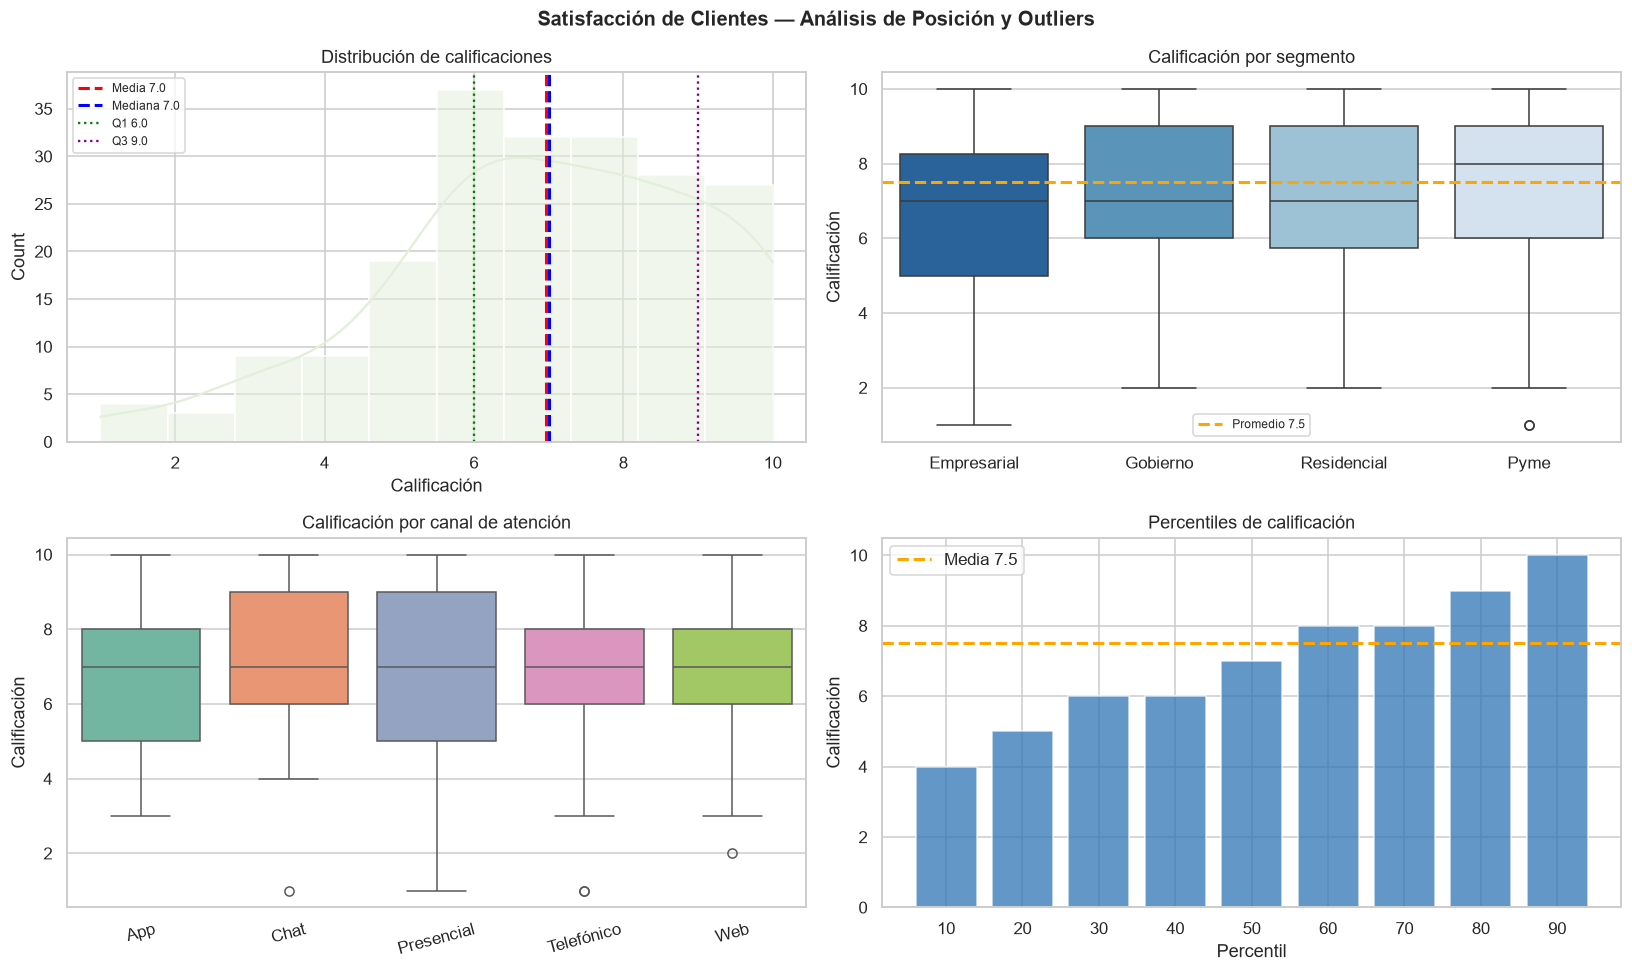

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Satisfacción de Clientes — Análisis de Posición y Outliers',
             fontweight='bold', fontsize=13)

# 1. Histograma calificación
sns.histplot(c, bins=10, kde=True, ax=axes[0,0], color='#E2EFDA', edgecolor='white')
axes[0,0].axvline(c.mean(),   color='red',   linestyle='--', linewidth=2,
                  label=f'Media {c.mean():.1f}')
axes[0,0].axvline(c.median(), color='blue',  linestyle='--', linewidth=2,
                  label=f'Mediana {c.median():.1f}')
axes[0,0].axvline(q1_c, color='green', linestyle=':', linewidth=1.5, label=f'Q1 {q1_c:.1f}')
axes[0,0].axvline(q3_c, color='purple',linestyle=':', linewidth=1.5, label=f'Q3 {q3_c:.1f}')
axes[0,0].set_title('Distribución de calificaciones')
axes[0,0].set_xlabel('Calificación')
axes[0,0].legend(fontsize=8)

# 2. Boxplot por segmento
orden_seg = df2.groupby('segmento')['calificacion'].median().sort_values().index
sns.boxplot(data=df2, x='segmento', y='calificacion',
            order=orden_seg, palette='Blues_r', ax=axes[0,1])
axes[0,1].axhline(7.5, color='orange', linestyle='--', linewidth=2, label='Promedio 7.5')
axes[0,1].set_title('Calificación por segmento')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Calificación')
axes[0,1].legend(fontsize=8)

# 3. Boxplot por canal
orden_can = df2.groupby('canal')['calificacion'].median().sort_values().index
sns.boxplot(data=df2, x='canal', y='calificacion',
            order=orden_can, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Calificación por canal de atención')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Calificación')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Percentiles visualizados como barras
pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vals = [c.quantile(p/100) for p in pcts]
axes[1,1].bar(pcts, vals, width=8, color='#2E75B6', alpha=0.75, edgecolor='white')
axes[1,1].axhline(7.5, color='orange', linestyle='--', linewidth=2, label='Media 7.5')
axes[1,1].set_title('Percentiles de calificación')
axes[1,1].set_xlabel('Percentil')
axes[1,1].set_ylabel('Calificación')
axes[1,1].set_xticks(pcts)
axes[1,1].legend()

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 4 — Concluye y responde al ejecutivo:

In [22]:
# Datos para responder
pct_bajo_6 = (c < 6).mean() * 100
pct_sobre_8 = (c >= 8).mean() * 100
print(f'% clientes con calificación < 6:  {pct_bajo_6:.1f}%')
print(f'% clientes con calificación >= 8: {pct_sobre_8:.1f}%')
print(f'Media: {c.mean():.2f} | Mediana: {c.median():.2f} | Q1: {q1_c} | Q3: {q3_c}')
print()

# ✏️ ¿El promedio de 7.5 representa a la mayoría de los clientes? Justifica con los cuartiles.
r_repr = ""

# ✏️ ¿Qué canal de atención tiene más variabilidad en las calificaciones?
r_canal = ""

# ✏️ ¿Qué segmento de clientes muestra calificaciones más bajas?
r_segmento = ""

# ✏️ ¿Qué le dirías al ejecutivo sobre el promedio de 7.5?
r_ejecutivo = ""

print('--- RESPUESTAS AL EJECUTIVO ---')
print(f'¿Promedio representativo?: {r_repr}')
print(f'Canal más variable:        {r_canal}')
print(f'Segmento más bajo:         {r_segmento}')
print(f'Mensaje al ejecutivo:      {r_ejecutivo}')

% clientes con calificación < 6:  22.0%
% clientes con calificación >= 8: 43.5%
Media: 6.96 | Mediana: 7.00 | Q1: 6.0 | Q3: 9.0

--- RESPUESTAS AL EJECUTIVO ---
¿Promedio representativo?: 
Canal más variable:        
Segmento más bajo:         
Mensaje al ejecutivo:      


---
## 📋 Resumen de funciones y buenas prácticas

| Medida | Función | Descripción |
|--------|---------|-------------|
| Cuartiles Q1/Q2/Q3 | `serie.quantile(0.25/0.50/0.75)` | Divide en 4 partes iguales |
| Percentil P | `np.percentile(datos, P)` | Divide en 100 partes |
| Quintil | `np.percentile(datos, 20/40/60/80)` | Divide en 5 partes |
| Decil | `np.percentile(datos, 10..90)` | Divide en 10 partes |
| IQR | `Q3 - Q1` | Rango del 50% central |
| Límite IQR inferior | `Q1 - 1.5 × IQR` | Umbral bajo para outliers |
| Límite IQR superior | `Q3 + 1.5 × IQR` | Umbral alto para outliers |
| Asignar decil | `pd.qcut(serie, q=10)` | Etiqueta cada valor con su decil |

**Boxplot vs Histograma:**

| Criterio | Histograma | Boxplot |
|----------|-----------|--------|
| Forma de distribución | ✅ Muy claro | ❌ No muestra |
| Outliers | ❌ Difícil detectar | ✅ Muy claro |
| Comparar grupos | ❌ Complejo | ✅ Ideal |
| Cuartiles explícitos | ❌ No muestra | ✅ Sí muestra |
| Espacio visual | ❌ Ocupa más | ✅ Compacto |

> 💡 **P90 para SLA:** En logística, usar el percentil 90 como tiempo máximo garantizado es más honesto que la media, porque asegura que el 90% de los clientes recibirá su pedido dentro de ese tiempo.

> 💡 **Nunca eliminar outliers automáticamente.** Siempre pregunta: ¿es un error de captura, un evento real extraordinario o un problema operacional que merece atención?